# 📓 `12_drl_training.ipynb`

# 📓 Week 12 — DRL Training: Reward Tuning + Curriculum Learning

## Dependency on Week 11
This notebook **requires** `checkpoints/ppo_agent.pt` from NB11.
It:
1. Loads NB11's agent for warm-start
2. Extends NB11's `NetworkSecurityEnv` with curriculum sampling
3. Overrides NB11's reward with a shaped reward engine
4. Trains for 3,000 more episodes targeting reward ≥ 0.70

---

## 🎯 Week 12 Objective

Fix the two root causes of poor performance:

### Root Cause 1 — Cold Start
```
NB11: Agent sees all 15 classes from episode 1
→ MITM appears only 0.4% of time
→ Agent never learns to handle it
```

### Root Cause 2 — Sparse Reward
```
NB11: correct → +1.0   wrong → −0.5
→ 15 classes × 5 actions = 75 combinations
→ Only 15 are correct → agent gets −0.5 most of the time early on
→ Gradient signal too noisy
```

### Solution: Curriculum + Shaped Reward
```
Curriculum:
  Stage 1 (Ep 1–500):    Normal, DDoS_TCP           (2 classes)
  Stage 2 (Ep 501–1200): + DDoS_UDP/ICMP/HTTP, Port_Scanning (6 classes)
  Stage 3 (Ep 1201–2000):+ SQL, XSS, MITM, Vuln_scanner     (10 classes)
  Stage 4 (Ep 2001–3000): All 15 classes

Shaped reward (7 components):
  Base     ← scale by detection confidence
  Rare     ← +1.0 bonus for MITM/Ransomware/Fingerprinting
  Severity ← extra penalty for missing dangerous attacks
  Overkill ← penalty for unnecessarily harsh action
  Loop     ← penalty for repeating same wrong action
  Progress ← +0.1 every correct step (dense signal)
  Streak   ← +0.3 every 5 consecutive resolutions
```

---

## 📋 Notebook Roadmap

| Step | Task |
|------|------|
| 1 | Imports — same constants as NB11 |
| 2 | Load + validate NB11 checkpoint |
| 3 | RewardEngine v2 |
| 4 | CurriculumScheduler |
| 5 | CurriculumSecurityEnv (extends NB11 env) |
| 6 | PPO classes (identical to NB11) |
| 7 | Training loop with curriculum |
| 8 | Training analysis plots |
| 9 | Full evaluation report |
| 10 | Save trained agent |

## 🧱 Step 1 — Imports (identical constants to NB11)

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
import json
import time
import math
import random
from pathlib     import Path
from typing      import List, Tuple, Dict, Optional
from collections import deque, defaultdict
from dataclasses import dataclass

# ── Data ──────────────────────────────────────────────────────────────────────
import numpy  as np
import pandas as pd

# ── Deep Learning ─────────────────────────────────────────────────────────────
import torch
import torch.nn            as nn
import torch.nn.functional as F
from torch.optim           import Adam
from torch.distributions   import Categorical

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot    as plt
import matplotlib.gridspec  as gridspec

warnings.filterwarnings('ignore')

# ── Plot theme ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#16162a',
    'axes.edgecolor' : '#444477', 'axes.labelcolor': '#ccccff',
    'xtick.color'    : '#aaaacc', 'ytick.color'    : '#aaaacc',
    'text.color'     : '#e0e0ff', 'grid.color'     : '#2a2a4a',
    'grid.linestyle' : '--',      'grid.alpha'     : 0.4,
    'font.family'    : 'DejaVu Sans',
    'legend.facecolor': '#1a1a2e','legend.edgecolor': '#444477',
})
ACCENT = '#7c6cfa'; GREEN = '#4ecca3'; RED = '#fc5c65'
YELLOW = '#f7b731'; BLUE  = '#45aaf2'; ORANGE = '#fd9644'
PALETTE = ['#7c6cfa','#4ecca3','#f7b731','#fc5c65','#45aaf2',
           '#fd9644','#26de81','#a55eea','#2bcbba','#eb3b5a',
           '#20bf6b','#0fb9b1','#8854d0','#4b6584','#778ca3']

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR  = Path('..')
CKPT_DIR  = BASE_DIR / 'checkpoints'
OUT_DIR   = BASE_DIR / 'outputs' / 'figures'
REP_DIR   = BASE_DIR / 'outputs' / 'reports'

NB11_CKPT    = CKPT_DIR / 'ppo_agent.pt'          # ← NB11 output
BEST_CKPT    = CKPT_DIR / 'ppo_agent_trained.pt'  # ← NB12 best
LAST_CKPT    = CKPT_DIR / 'ppo_agent_trained_last.pt'

for d in [CKPT_DIR, OUT_DIR, REP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ─────────────────────────────────────────────────────────────────────────────
# SHARED CONSTANTS — must be IDENTICAL to NB11
# ─────────────────────────────────────────────────────────────────────────────
CLASS_NAMES = [
    'Backdoor', 'DDoS_HTTP', 'DDoS_ICMP', 'DDoS_TCP', 'DDoS_UDP',
    'Fingerprinting', 'MITM', 'Normal', 'Password', 'Port_Scanning',
    'Ransomware', 'SQL_injection', 'Uploading', 'Vulnerability_scanner', 'XSS',
]
ACTION_NAMES = [
    'BLOCK_IP', 'RESET_CONNECTION', 'RESTART_SERVICE',
    'ISOLATE_DEVICE', 'LOG_AND_ALERT',
]
N_CLASSES   = 15;  N_ACTIONS = 5
N_NET_STATS = 10;  N_HISTORY = 5
STATE_DIM   = N_CLASSES + N_NET_STATS + N_HISTORY   # 30
CLS_TO_IDX  = {cls: i for i, cls in enumerate(CLASS_NAMES)}

OPTIMAL_ACTION: Dict[str, int] = {
    'Normal': 4, 'Fingerprinting': 4,
    'Port_Scanning': 0, 'DDoS_TCP': 0, 'DDoS_UDP': 0,
    'DDoS_ICMP': 0, 'DDoS_HTTP': 0,
    'SQL_injection': 1, 'XSS': 1, 'MITM': 1,
    'Uploading': 2, 'Backdoor': 2, 'Password': 2, 'Vulnerability_scanner': 2,
    'Ransomware': 3,
}
CLASS_SEVERITY: Dict[str, int] = {
    'Normal': 0, 'Fingerprinting': 1, 'Port_Scanning': 2,
    'Vulnerability_scanner': 3, 'DDoS_ICMP': 4, 'DDoS_HTTP': 4,
    'DDoS_UDP': 4, 'DDoS_TCP': 5, 'XSS': 5, 'SQL_injection': 6,
    'MITM': 7, 'Password': 7, 'Uploading': 7,
    'Backdoor': 8, 'Ransomware': 10,
}
ACTION_COST: Dict[int, float] = {0:0.30, 1:0.20, 2:0.40, 3:0.80, 4:0.05}
RARE_CLASSES = {'MITM', 'Fingerprinting', 'Ransomware'}

# PPO hyperparams (same as NB11)
PPO_LR=3e-4; PPO_GAMMA=0.99; PPO_GAE_LAMBDA=0.95
PPO_CLIP_EPS=0.20; PPO_EPOCHS=10; PPO_BATCH_SIZE=64
PPO_VALUE_COEF=0.50; PPO_ENTROPY_COEF=0.01
PPO_MAX_GRAD=0.50;  HIDDEN_DIM=128

# Week 12 training config
N_EPISODES   = 3_000
MAX_STEPS    = 200
UPDATE_EVERY = 20
TARGET_REWARD= 0.70

print('✅ Setup complete — constants match NB11.')
print(f'   Device     : {DEVICE}')
print(f'   STATE_DIM  : {STATE_DIM}')
print(f'   N_CLASSES  : {N_CLASSES}  (same as NB11)')
print(f'   N_ACTIONS  : {N_ACTIONS}  (same as NB11)')

✅ Setup complete — constants match NB11.
   Device     : cuda
   STATE_DIM  : 30
   N_CLASSES  : 15  (same as NB11)
   N_ACTIONS  : 5  (same as NB11)


## 📁 Step 2 — Load & Validate NB11 Checkpoint

In [2]:
assert NB11_CKPT.exists(), (
    f'❌ {NB11_CKPT} not found.\n'
    f'   Run Notebook 11 (11_drl_ppo_agent.ipynb) first.'
)

print(f'📁 Loading NB11 checkpoint: {NB11_CKPT}')
nb11_ckpt = torch.load(NB11_CKPT, map_location=DEVICE, weights_only=False)

# ── Validate checkpoint compatibility ━━━━━━━━━━━━━━━━━━━━━━━━━
print('\n🔍 Validating checkpoint compatibility with NB12 …\n')

checks = {
    'state_dim matches'   : nb11_ckpt.get('state_dim')  == STATE_DIM,
    'action_dim matches'  : nb11_ckpt.get('action_dim') == N_ACTIONS,
    'hidden_dim matches'  : nb11_ckpt.get('hidden_dim', HIDDEN_DIM) == HIDDEN_DIM,
    'class_names match'   : nb11_ckpt.get('class_names') == CLASS_NAMES,
    'model weights exist' : 'model_state_dict' in nb11_ckpt,
    'optimizer exists'    : 'optimizer_state'  in nb11_ckpt,
}

all_ok = True
for check, passed in checks.items():
    icon = '✅' if passed else '❌'
    print(f'   {icon} {check}')
    if not passed:
        all_ok = False

assert all_ok, (
    '❌ Checkpoint incompatible with NB12.\n'
    '   Ensure NB11 was run with the same constants.'
)

print(f'\n✅ Checkpoint valid.')
print(f'   NB11 trained for    : {nb11_ckpt["episode"]} episodes')
print(f'   NB11 total steps    : {nb11_ckpt["total_steps"]: ,}')
print(f'   NB11 best reward    : {nb11_ckpt["best_reward"]: .4f}')
print(f'   Target reward       : {TARGET_REWARD}')
print(f'   Needs improvement   : '
      f'{"No — already at target!" if nb11_ckpt["best_reward"] >= TARGET_REWARD else "Yes — curriculum will fix this"}')

📁 Loading NB11 checkpoint: ..\checkpoints\ppo_agent.pt

🔍 Validating checkpoint compatibility with NB12 …

   ✅ state_dim matches
   ✅ action_dim matches
   ✅ hidden_dim matches
   ✅ class_names match
   ✅ model weights exist
   ✅ optimizer exists

✅ Checkpoint valid.
   NB11 trained for    : 1418 episodes
   NB11 total steps    :  251,591
   NB11 best reward    :  117.6980
   Target reward       : 0.7
   Needs improvement   : No — already at target!


## 🔥 Step 3 — Reward Engine v2 (Shaped Rewards)

7 reward components providing dense, informative signal:

| Component | Trigger | Value |
|-----------|---------|-------|
| Base | correct/wrong | ±scaled |
| Confidence scale | always | × detect_conf |
| Rare bonus | MITM/Ransomware/Fingerprinting correct | +1.0 |
| Severity penalty | wrong on dangerous attack | −0.3×sev |
| Overkill penalty | action too harsh for class | −0.25×gap |
| Loop penalty | same wrong action ×3 | −0.2 |
| Progress | every correct step | +0.1 |
| Streak | every 5 resolved | +0.3 |

In [3]:
class RewardEngine:
    """
    Week 12 shaped reward — replaces NB11's flat reward.
    Used by CurriculumSecurityEnv._compute_reward().
    """

    # Severity order of actions (ascending disruption):
    _ACTION_ORDER = [4, 1, 0, 2, 3]
    # LOG < RESET < BLOCK < RESTART < ISOLATE

    def compute(
        self,
        true_class    : str,
        action        : int,
        confidence    : float,
        action_history: deque,
        resolved_count: int,
    ) -> Tuple[float, Dict]:

        optimal    = OPTIMAL_ACTION[true_class]
        is_correct = (action == optimal)
        is_normal  = (true_class == 'Normal')
        severity   = CLASS_SEVERITY[true_class]
        sev_norm   = severity / 10.0
        is_rare    = (true_class in RARE_CLASSES)

        reward = 0.0
        bd     = {}

        # ── 1. Base reward ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        if is_normal and action == 4:
            bd['base'] = +0.5
        elif is_normal:
            bd['base'] = -0.3 * ACTION_COST[action]
        elif is_correct:
            bd['base'] = +1.0 * max(confidence, 0.5)
        else:
            bd['base'] = -0.5 * (0.5 + sev_norm * 0.5)
        reward += bd['base']

        # ── 2. Rare class bonus ━━━━━━━━━━━━━━━━
        if is_rare and is_correct:
            bd['rare_bonus'] = +1.0
            reward += bd['rare_bonus']

        # ── 3. Severity penalty ━━━━━━━━━━━━
        if not is_correct and not is_normal and severity >= 7:
            bd['severity_pen'] = -0.3 * sev_norm
            reward += bd['severity_pen']

        # ── 4. Overkill penalty ━━━━━━━━━━━━━━━
        if not is_normal:
            opt_i = self._ACTION_ORDER.index(optimal)
            act_i = self._ACTION_ORDER.index(action)
            if act_i > opt_i + 1:
                bd['overkill'] = -0.25 * (act_i - opt_i)
                reward += bd['overkill']

        # ── 5. Loop penalty ━━━━━━
        hist = list(action_history)
        if (len(hist) >= 3
                and hist[-1] == action
                and hist[-2] == action
                and not is_correct):
            bd['loop'] = -0.20
            reward    += bd['loop']

        # ── 6. Progress reward ━━━━
        if is_correct:
            bd['progress'] = +0.10
            reward += bd['progress']

        # ── 7. Streak bonus ━━━━━
        if is_correct and resolved_count > 0 and resolved_count % 5 == 0:
            bd['streak'] = +0.30
            reward      += bd['streak']

        bd['total']    = reward
        bd['is_correct'] = is_correct
        bd['optimal']  = ACTION_NAMES[optimal]
        bd['chosen']   = ACTION_NAMES[action]
        return float(reward), bd


# ── Verify reward engine ━━━━━━━━
re_engine = RewardEngine()
print('🔥 RewardEngine v2 — verification:\n')
print(f'  {"Scenario":<45} {"Reward":>8}')
print('  ' + '-' * 55)

test_cases = [
    ('Normal   → LOG_AND_ALERT ✅',  'Normal',    4, 0.95, deque([4],maxlen=5), 0),
    ('Normal   → BLOCK_IP ❌',       'Normal',    0, 0.95, deque([4],maxlen=5), 0),
    ('DDoS_TCP → BLOCK_IP ✅ hi-conf','DDoS_TCP', 0, 0.94, deque([0],maxlen=5), 0),
    ('DDoS_TCP → BLOCK_IP ✅ lo-conf','DDoS_TCP', 0, 0.55, deque([0],maxlen=5), 0),
    ('DDoS_TCP → LOG_AND_ALERT ❌',  'DDoS_TCP',  4, 0.90, deque([4],maxlen=5), 0),
    ('Ransomware→ISOLATE ✅ rare',   'Ransomware',3, 0.88, deque([3],maxlen=5), 0),
    ('Ransomware→LOG ❌ severe',     'Ransomware',4, 0.88, deque([4],maxlen=5), 0),
    ('MITM → RESET ✅ rare',         'MITM',      1, 0.91, deque([1],maxlen=5), 0),
    ('DDoS_TCP→ISOLATE ❌ overkill', 'DDoS_TCP',  3, 0.85, deque([3],maxlen=5), 0),
    ('Loop: same wrong ×3',          'DDoS_TCP',  4, 0.85, deque([4,4],maxlen=5),0),
    ('Streak bonus at 5 resolved',   'DDoS_UDP',  0, 0.90, deque([0],maxlen=5), 5),
]

for desc, cls, act, conf, hist, resolved in test_cases:
    r, bd = re_engine.compute(cls, act, conf, hist, resolved)
    parts = ' + '.join(
        f'{k}={v:+.2f}' for k, v in bd.items()
        if k not in ('total','is_correct','optimal','chosen') and isinstance(v, float)
    )
    print(f'  {desc:<45} {r:>8.3f}  [{parts}]')

🔥 RewardEngine v2 — verification:

  Scenario                                        Reward
  -------------------------------------------------------
  Normal   → LOG_AND_ALERT ✅                       0.600  [base=+0.50 + progress=+0.10]
  Normal   → BLOCK_IP ❌                           -0.090  [base=-0.09]
  DDoS_TCP → BLOCK_IP ✅ hi-conf                    1.040  [base=+0.94 + progress=+0.10]
  DDoS_TCP → BLOCK_IP ✅ lo-conf                    0.650  [base=+0.55 + progress=+0.10]
  DDoS_TCP → LOG_AND_ALERT ❌                      -0.375  [base=-0.38]
  Ransomware→ISOLATE ✅ rare                        1.980  [base=+0.88 + rare_bonus=+1.00 + progress=+0.10]
  Ransomware→LOG ❌ severe                         -0.800  [base=-0.50 + severity_pen=-0.30]
  MITM → RESET ✅ rare                              2.010  [base=+0.91 + rare_bonus=+1.00 + progress=+0.10]
  DDoS_TCP→ISOLATE ❌ overkill                     -0.875  [base=-0.38 + overkill=-0.50]
  Loop: same wrong ×3                             

## 📚 Step 4 — Curriculum Scheduler

In [4]:
@dataclass
class Stage:
    name          : str
    classes       : List[str]
    start_ep      : int
    end_ep        : int
    target_reward : float = TARGET_REWARD


class CurriculumScheduler:
    """
    Progressively introduces attack classes in 4 stages.

    Advances when rolling_reward ≥ target OR episode ≥ end_ep.
    """

    STAGES = [
        Stage(
            name    = 'Stage 1 — Binary',
            classes = ['Normal', 'DDoS_TCP'],
            start_ep= 0, end_ep=500,
        ),
        Stage(
            name    = 'Stage 2 — DDoS Family',
            classes = ['Normal','DDoS_TCP','DDoS_UDP',
                       'DDoS_ICMP','DDoS_HTTP','Port_Scanning'],
            start_ep= 500, end_ep=1200,
        ),
        Stage(
            name    = 'Stage 3 — Injection + Recon',
            classes = ['Normal','DDoS_TCP','DDoS_UDP','DDoS_ICMP',
                       'DDoS_HTTP','Port_Scanning',
                       'SQL_injection','XSS','MITM',
                       'Vulnerability_scanner'],
            start_ep= 1200, end_ep=2000,
        ),
        Stage(
            name    = 'Stage 4 — All 15 Classes',
            classes = CLASS_NAMES,
            start_ep= 2000, end_ep=3000,
        ),
    ]

    def __init__(self):
        self.idx      = 0
        self.advances = []   # [(episode, stage_name)]

    @property
    def stage(self) -> Stage:
        return self.STAGES[self.idx]

    @property
    def active(self) -> List[str]:
        return self.stage.classes

    @property
    def n_active(self) -> int:
        return len(self.active)

    @property
    def at_final(self) -> bool:
        return self.idx >= len(self.STAGES) - 1

    def update(self, episode: int, rolling_reward: float) -> bool:
        """Check + apply advance. Returns True if advanced."""
        if self.at_final:
            return False
        if (rolling_reward >= self.stage.target_reward
                or episode >= self.stage.end_ep):
            old = self.stage.name
            self.idx = min(self.idx + 1, len(self.STAGES) - 1)
            self.advances.append((episode, self.stage.name))
            print(f'\n{"="*60}')
            print(f'  📚 Curriculum ADVANCE at episode {episode}')
            print(f'     {old} → {self.stage.name}')
            print(f'     Classes now : {self.n_active}')
            print(f'     Trigger     : reward={rolling_reward:.4f}')
            print(f'{"="*60}\n')
            return True
        return False

    def class_weights(self) -> np.ndarray:
        """
        Sampling weights — upweight rare and severe classes
        so agent sees balanced experience.
        """
        w = np.ones(self.n_active, dtype=np.float32)
        for i, cls in enumerate(self.active):
            if cls in RARE_CLASSES:
                w[i] = 4.0    # rare classes: 4×
            elif CLASS_SEVERITY.get(cls, 0) >= 6:
                w[i] = 2.0    # high-severity: 2×
        return w / w.sum()


sched = CurriculumScheduler()
print('📚 Curriculum Schedule:\n')
for i, s in enumerate(CurriculumScheduler.STAGES):
    print(f'  Stage {i+1}: {s.name}')
    print(f'    Episodes : {s.start_ep}–{s.end_ep}')
    print(f'    Classes  : {len(s.classes)}')
    print(f'    {s.classes}')
    print()


📚 Curriculum Schedule:

  Stage 1: Stage 1 — Binary
    Episodes : 0–500
    Classes  : 2
    ['Normal', 'DDoS_TCP']

  Stage 2: Stage 2 — DDoS Family
    Episodes : 500–1200
    Classes  : 6
    ['Normal', 'DDoS_TCP', 'DDoS_UDP', 'DDoS_ICMP', 'DDoS_HTTP', 'Port_Scanning']

  Stage 3: Stage 3 — Injection + Recon
    Episodes : 1200–2000
    Classes  : 10
    ['Normal', 'DDoS_TCP', 'DDoS_UDP', 'DDoS_ICMP', 'DDoS_HTTP', 'Port_Scanning', 'SQL_injection', 'XSS', 'MITM', 'Vulnerability_scanner']

  Stage 4: Stage 4 — All 15 Classes
    Episodes : 2000–3000
    Classes  : 15
    ['Backdoor', 'DDoS_HTTP', 'DDoS_ICMP', 'DDoS_TCP', 'DDoS_UDP', 'Fingerprinting', 'MITM', 'Normal', 'Password', 'Port_Scanning', 'Ransomware', 'SQL_injection', 'Uploading', 'Vulnerability_scanner', 'XSS']



## 🌐 Step 5 — CurriculumSecurityEnv

**Extends NB11's `NetworkSecurityEnv`** — overrides only two methods:
- `_sample_threat()` → uses curriculum class weights
- `_compute_reward()` → uses RewardEngine v2 shaped rewards

All other methods (`reset`, `step`, `_build_state`, etc.) are
inherited unchanged from NB11.

In [5]:
# ── Copy NB11 NetworkSecurityEnv (required as base class) ━━━━━━━━━━━━━━━━━━━━━━━━━
# In practice you would import this from nb11 or a shared module.
# We redefine it here verbatim so the notebook is self-contained.

class NetworkSecurityEnv:
    """NB11 base environment — copied verbatim. Do not modify."""

    def __init__(self, active_classes=None, max_steps=100,
                 noise_level=0.05, rng_seed=42):
        self.all_classes    = CLASS_NAMES
        self.active_classes = active_classes or CLASS_NAMES
        self.max_steps      = max_steps
        self.noise_level    = noise_level
        self.rng            = np.random.RandomState(rng_seed)
        self.true_class     = ''
        self.true_class_idx = 0
        self.attack_probs   = np.zeros(N_CLASSES, np.float32)
        self.confidence     = 0.0
        self.network_stats  = np.zeros(N_NET_STATS, np.float32)
        self.action_history = deque([0]*N_HISTORY, maxlen=N_HISTORY)
        self.step_count     = 0
        self.resolved_count = 0
        self.consecutive_bad= 0

    def reset(self):
        self.step_count      = 0
        self.resolved_count  = 0
        self.consecutive_bad = 0
        self.action_history  = deque([0]*N_HISTORY, maxlen=N_HISTORY)
        self._sample_threat()
        return self._build_state()

    def step(self, action):
        self.step_count += 1
        self.action_history.append(action)
        reward, info = self._compute_reward(action)
        if info['is_correct']:
            self.consecutive_bad  = 0
            self.resolved_count  += 1
            self.network_stats    = np.clip(
                self.network_stats * 0.6
                + self.rng.normal(0.3, 0.05, N_NET_STATS).astype(np.float32),
                0.0, 1.0)
        else:
            self.consecutive_bad += 1
            self.network_stats    = np.clip(
                self.network_stats * 1.05
                + self.rng.normal(0.0, 0.05, N_NET_STATS).astype(np.float32),
                0.0, 1.0)
        if info['is_correct'] or self.step_count % 10 == 0:
            self._sample_threat()
        done = (self.step_count >= self.max_steps
                or self.consecutive_bad >= 10)
        info.update({'true_class': self.true_class,
                     'action_name': ACTION_NAMES[action],
                     'optimal_action': ACTION_NAMES[OPTIMAL_ACTION[self.true_class]]})
        return self._build_state(), float(reward), done, info

    def _sample_threat(self):
        idx = self.rng.randint(0, len(self.active_classes))
        self.true_class      = self.active_classes[idx]
        self.true_class_idx  = CLS_TO_IDX[self.true_class]
        self.attack_probs    = self._simulate_probs()
        self.confidence      = float(self.attack_probs[self.true_class_idx])
        self.network_stats   = self._simulate_net_stats()

    def _simulate_probs(self):
        probs = np.zeros(N_CLASSES, dtype=np.float32)
        if self.rng.random() < 0.85:
            conf = 0.70 + self.rng.random() * 0.25
            probs[self.true_class_idx] = conf
            other = [i for i in range(N_CLASSES) if i != self.true_class_idx]
            noise = self.rng.dirichlet(np.ones(len(other)) * 0.5)
            for i, oi in enumerate(other):
                probs[oi] = noise[i] * (1.0 - conf)
        else:
            probs = self.rng.dirichlet(np.ones(N_CLASSES)*0.3).astype(np.float32)
        return probs

    def _simulate_net_stats(self):
        SIGS = {
            'DDoS_TCP':[0.9,0.6,0.9,0.7,0.9,0.7,0.9,0.8,0.8,0.8],
            'DDoS_UDP':[0.9,0.7,0.8,0.6,0.9,0.8,0.9,0.9,0.7,0.8],
            'DDoS_ICMP':[0.8,0.5,0.7,0.5,0.8,0.6,0.8,0.8,0.6,0.7],
            'DDoS_HTTP':[0.7,0.4,0.8,0.8,0.7,0.5,0.8,0.7,0.5,0.7],
            'Ransomware':[0.3,0.2,0.9,0.9,0.3,0.4,0.6,0.3,0.4,0.9],
            'SQL_injection':[0.4,0.1,0.5,0.4,0.4,0.3,0.3,0.3,0.2,0.6],
            'MITM':[0.3,0.3,0.4,0.4,0.3,0.4,0.4,0.5,0.3,0.7],
            'Backdoor':[0.2,0.1,0.6,0.7,0.2,0.3,0.4,0.2,0.2,0.8],
            'Port_Scanning':[0.6,0.1,0.3,0.2,0.6,0.2,0.4,0.3,0.3,0.4],
            'Normal':[0.3,0.1,0.4,0.5,0.3,0.1,0.4,0.2,0.1,0.1],
        }
        sig = np.array(SIGS.get(self.true_class,
               [0.3,0.1,0.4,0.5,0.3,0.1,0.4,0.2,0.1,0.1]), np.float32)
        return np.clip(sig + self.rng.normal(0,self.noise_level,N_NET_STATS)
                       .astype(np.float32), 0.0, 1.0)

    def _compute_reward(self, action):
        optimal = OPTIMAL_ACTION[self.true_class]
        is_correct = (action == optimal)
        is_normal  = (self.true_class == 'Normal')
        sev_norm   = CLASS_SEVERITY[self.true_class] / 10.0
        hist       = list(self.action_history)
        is_rep     = (len(hist)>=2 and hist[-1]==action
                      and hist[-2]==action and not is_correct)
        if is_normal and action==4:   r = +0.50
        elif is_normal:               r = -0.30 * ACTION_COST[action]
        elif is_correct:              r = +1.00 * max(self.confidence,0.5)
        else:                         r = -0.50 * (0.5 + sev_norm*0.5)
        if is_rep: r -= 0.20
        return float(r), {'is_correct': is_correct, 'reward': r}

    def _build_state(self):
        hist = np.array(list(self.action_history), np.float32) / N_ACTIONS
        return np.concatenate([self.attack_probs, self.network_stats, hist])


class CurriculumSecurityEnv(NetworkSecurityEnv):
    def __init__(self, scheduler, reward_engine, max_steps=200):
        super().__init__(active_classes=CLASS_NAMES, max_steps=max_steps)
        self.scheduler     = scheduler
        self.reward_engine = reward_engine
        self.cls_correct   = defaultdict(int)
        self.cls_total     = defaultdict(int)

    def _sample_threat(self):
        active  = self.scheduler.active
        weights = self.scheduler.class_weights()
        idx     = self.rng.choice(len(active), p=weights)
        self.true_class     = active[idx]
        self.true_class_idx = CLS_TO_IDX[self.true_class]
        self.attack_probs   = self._simulate_probs()
        self.confidence     = float(self.attack_probs[self.true_class_idx])
        self.network_stats  = self._simulate_net_stats()

    def _compute_reward(self, action):
        reward, info = self.reward_engine.compute(
            true_class    = self.true_class, action = action,
            confidence    = self.confidence, action_history= self.action_history,
            resolved_count= self.resolved_count)
        self.cls_total  [self.true_class] += 1
        self.cls_correct[self.true_class] += int(info['is_correct'])
        return reward, info

    def get_class_accuracy(self): 
        return {cls: self.cls_correct[cls]/max(self.cls_total[cls], 1) for cls in CLASS_NAMES}

    def reset_class_stats(self): 
        self.cls_correct.clear(); self.cls_total.clear()


## 🧠 Step 6 — PPO Classes (Identical to NB11)

**These must be byte-for-byte identical to NB11.**


In [6]:
class PPOActorCritic(nn.Module):
    def __init__(self, state_dim=30, action_dim=5, hidden_dim=128):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU())
        self.actor_head = nn.Sequential(nn.Linear(hidden_dim, 64), nn.ReLU(), nn.Linear(64, action_dim))
        self.critic_head = nn.Sequential(nn.Linear(hidden_dim, 64), nn.ReLU(), nn.Linear(64, 1))
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=1.414)
                nn.init.constant_(m.bias, 0.0)
        nn.init.orthogonal_(self.actor_head[-1].weight, gain=0.01)
        nn.init.orthogonal_(self.critic_head[-1].weight, gain=1.00)

    def forward(self, x):
        f = self.backbone(x)
        return self.actor_head(f), self.critic_head(f)

    def get_action_and_value(self, state, action=None):
        logits, value = self.forward(state)
        dist = Categorical(logits=logits)
        if action is None: action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), value.squeeze(-1)

    def get_value(self, state):
        _, v = self.forward(state)
        return v.squeeze(-1)

class RolloutBuffer:
    __slots__ = ['states','actions','log_probs','rewards','values','dones']
    def __init__(self):
        for s in self.__slots__: setattr(self, s, [])
    def add(self, s, a, lp, r, v, d):
        self.states.append(s); self.actions.append(a)
        self.log_probs.append(lp); self.rewards.append(r)
        self.values.append(v); self.dones.append(d)
    def clear(self): 
        for s in self.__slots__: getattr(self, s).clear()
    def __len__(self): return len(self.states)

class PPOAgent:
    def __init__(self, state_dim=30, action_dim=5, hidden_dim=128, lr=3e-4):
        self.gamma=0.99; self.gae_lambda=0.95; self.clip_eps=0.2; self.ppo_epochs=10
        self.batch_size=64; self.value_coef=0.5; self.entropy_coef=0.01; self.max_grad=0.5
        self.device=DEVICE
        self.network   = PPOActorCritic(state_dim, action_dim, hidden_dim).to(DEVICE)
        self.optimizer = Adam(self.network.parameters(), lr=lr, eps=1e-5)
        self.buffer    = RolloutBuffer()
        self.total_steps=0; self.update_count=0; self.best_reward=-float('inf')

    @torch.no_grad()
    def select_action(self, state):
        s = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        a, lp, _, v = self.network.get_action_and_value(s)
        return a.item(), lp.item(), v.item()

    def compute_gae(self, last_value):
        N=len(self.buffer); advs=np.zeros(N,np.float32); gae=0.0
        for t in reversed(range(N)):
            nv   = last_value if t==N-1 else self.buffer.values[t+1]
            nd   = self.buffer.dones[t]
            delta= self.buffer.rewards[t]+self.gamma*nv*(1-nd)-self.buffer.values[t]
            gae  = delta+self.gamma*self.gae_lambda*(1-nd)*gae
            advs[t]=gae
        rets=advs+np.array(self.buffer.values,np.float32)
        return torch.FloatTensor(advs), torch.FloatTensor(rets)

    def update(self, last_value):
        advs,rets=self.compute_gae(last_value)
        states   =torch.FloatTensor(np.array(self.buffer.states)).to(self.device)
        actions  =torch.LongTensor(self.buffer.actions).to(self.device)
        old_lps  =torch.FloatTensor(self.buffer.log_probs).to(self.device)
        advs=advs.to(self.device); rets=rets.to(self.device)
        advs=(advs-advs.mean())/(advs.std()+1e-8)
        tl=pl=vl=el=nu=0
        for _ in range(self.ppo_epochs):
            idx=torch.randperm(len(states))
            for s in range(0,len(states),self.batch_size):
                mb=idx[s:s+self.batch_size]
                if len(mb)<2: continue
                _,nlp,ent,nv=self.network.get_action_and_value(states[mb],actions[mb])
                ratio=(nlp-old_lps[mb]).exp()
                clipped=ratio.clamp(1-self.clip_eps,1+self.clip_eps)
                p=-torch.min(ratio*advs[mb],clipped*advs[mb]).mean()
                v=F.mse_loss(nv,rets[mb])
                e=ent.mean()
                loss=p+0.5*v-0.01*e
                self.optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(self.network.parameters(),0.5)
                self.optimizer.step()
                tl+=loss.item();pl+=p.item();vl+=v.item();el+=e.item();nu+=1
        self.buffer.clear(); self.update_count+=1; n=max(nu,1)
        return {'total':tl/n,'policy':pl/n,'value':vl/n,'entropy':el/n}

    def save(self, path, episode, extra=None):
        state={'state_dim':30,'action_dim':5,'hidden_dim':128,
               'model_state_dict':self.network.state_dict(),
               'optimizer_state':self.optimizer.state_dict(),
               'episode':episode,'total_steps':self.total_steps,
               'update_count':self.update_count,'best_reward':self.best_reward}
        if extra: state.update(extra)
        torch.save(state, path)

agent = PPOAgent()
agent.network.load_state_dict(nb11_ckpt['model_state_dict'])
agent.optimizer.load_state_dict(nb11_ckpt['optimizer_state'])
agent.total_steps  = nb11_ckpt.get('total_steps', 0)
agent.update_count = nb11_ckpt.get('update_count', 0)
agent.best_reward  = nb11_ckpt.get('best_reward', -float('inf'))
print('✅ NB11 weights loaded — warm start.')

✅ NB11 weights loaded — warm start.


## 🚀 Step 7 — Training Loop with Curriculum

In [7]:
# ── Initialise ━━━━━━━━━━━━
scheduler     = CurriculumScheduler()
reward_engine = RewardEngine()
env           = CurriculumSecurityEnv(scheduler, reward_engine, MAX_STEPS)

history = {
    'ep_rewards'      : [], 'ep_accuracy'    : [],
    'ep_length'       : [], 'rolling_reward'  : [],
    'policy_loss'     : [], 'value_loss'      : [],
    'entropy'         : [], 'n_active_classes': [],
    'stage_idx'       : [],
}
class_acc_snaps = defaultdict(list)   # per-class accuracy snapshots

rolling_window = deque(maxlen=100)
t_start        = time.time()

print('🚀 PPO Training — Week 12 (Curriculum + Shaped Reward)')
print(f'   Episodes    : {N_EPISODES}  (warm-start from NB11)')
print(f'   Target      : reward ≥ {TARGET_REWARD}')
print(f'   Curriculum  : {len(CurriculumScheduler.STAGES)} stages')
print("=" * 65)

for episode in range(1, N_EPISODES + 1):
    state      = env.reset()
    ep_reward  = 0.0
    ep_correct = 0
    ep_steps   = 0
    done       = False
    while not done:
        action, log_prob, value = agent.select_action(state)
        next_state, reward, done, info = env.step(action)
        agent.buffer.add(state, action, log_prob, reward, value, float(done))
        ep_reward  += reward
        ep_steps   += 1
        ep_correct += int(info['is_correct'])
        agent.total_steps += 1
        state = next_state

    rolling_window.append(ep_reward)
    rolling_avg = float(np.mean(rolling_window))
    history['ep_rewards'].append(ep_reward)
    history['ep_accuracy'].append(ep_correct / max(ep_steps, 1))
    history['ep_length'].append(ep_steps)
    history['rolling_reward'].append(rolling_avg)
    history['n_active_classes'].append(scheduler.n_active)
    history['stage_idx'].append(scheduler.idx)

    if episode % UPDATE_EVERY == 0 and len(agent.buffer) > 0:
        with torch.no_grad():
            lv = agent.network.get_value(torch.FloatTensor(state).unsqueeze(0).to(DEVICE)).item()
        losses = agent.update(last_value=lv)
        history['policy_loss'].append(losses['policy'])
        history['value_loss'].append(losses['value'])
        history['entropy'].append(losses['entropy'])
        ca = env.get_class_accuracy()
        for cls, acc in ca.items(): class_acc_snaps[cls].append(acc)
        env.reset_class_stats()

    scheduler.update(episode, rolling_avg)

    if rolling_avg > agent.best_reward and episode >= 100:
        agent.best_reward = rolling_avg
        agent.save(BEST_CKPT, episode, extra={'history': history, 'curriculum_advances': scheduler.advances, 'rolling_avg': rolling_avg})

    if episode % 100 == 0:
        elapsed = time.time() - t_start
        met     = '✅' if rolling_avg >= TARGET_REWARD else '⏳'
        print(f'  Ep {episode:>5}/{N_EPISODES}  |  Reward: {rolling_avg:>7.4f}  |  Acc: {np.mean(history["ep_accuracy"][-100:])*100:>5.1f}%  |  Stage {scheduler.idx+1}/4 ({scheduler.n_active} cls)  |  {met}≥{TARGET_REWARD}  |  {elapsed:.0f}s')

agent.save(LAST_CKPT, N_EPISODES, extra={'history': history, 'curriculum_advances': scheduler.advances})
total_time = time.time() - t_start
print(f'\n✅ Training complete!')
print(f'   Total time       : {total_time:.0f}s ({total_time/60:.1f} min)')

🚀 PPO Training — Week 12 (Curriculum + Shaped Reward)
   Episodes    : 3000  (warm-start from NB11)
   Target      : reward ≥ 0.7
   Curriculum  : 4 stages

  📚 Curriculum ADVANCE at episode 2
     Stage 1 — Binary → Stage 2 — DDoS Family
     Classes now : 6
     Trigger     : reward=47.8393


  📚 Curriculum ADVANCE at episode 3
     Stage 2 — DDoS Family → Stage 3 — Injection + Recon
     Classes now : 10
     Trigger     : reward=85.7368


  📚 Curriculum ADVANCE at episode 4
     Stage 3 — Injection + Recon → Stage 4 — All 15 Classes
     Classes now : 15
     Trigger     : reward=102.4892

  Ep   100/3000  |  Reward: 161.5250  |  Acc:  76.5%  |  Stage 4/4 (15 cls)  |  ✅≥0.7  |  45s
  Ep   200/3000  |  Reward: 170.7561  |  Acc:  78.2%  |  Stage 4/4 (15 cls)  |  ✅≥0.7  |  86s
  Ep   300/3000  |  Reward: 167.3949  |  Acc:  78.2%  |  Stage 4/4 (15 cls)  |  ✅≥0.7  |  123s
  Ep   400/3000  |  Reward: 164.9032  |  Acc:  76.5%  |  Stage 4/4 (15 cls)  |  ✅≥0.7  |  178s
  Ep   500/3000  |  R

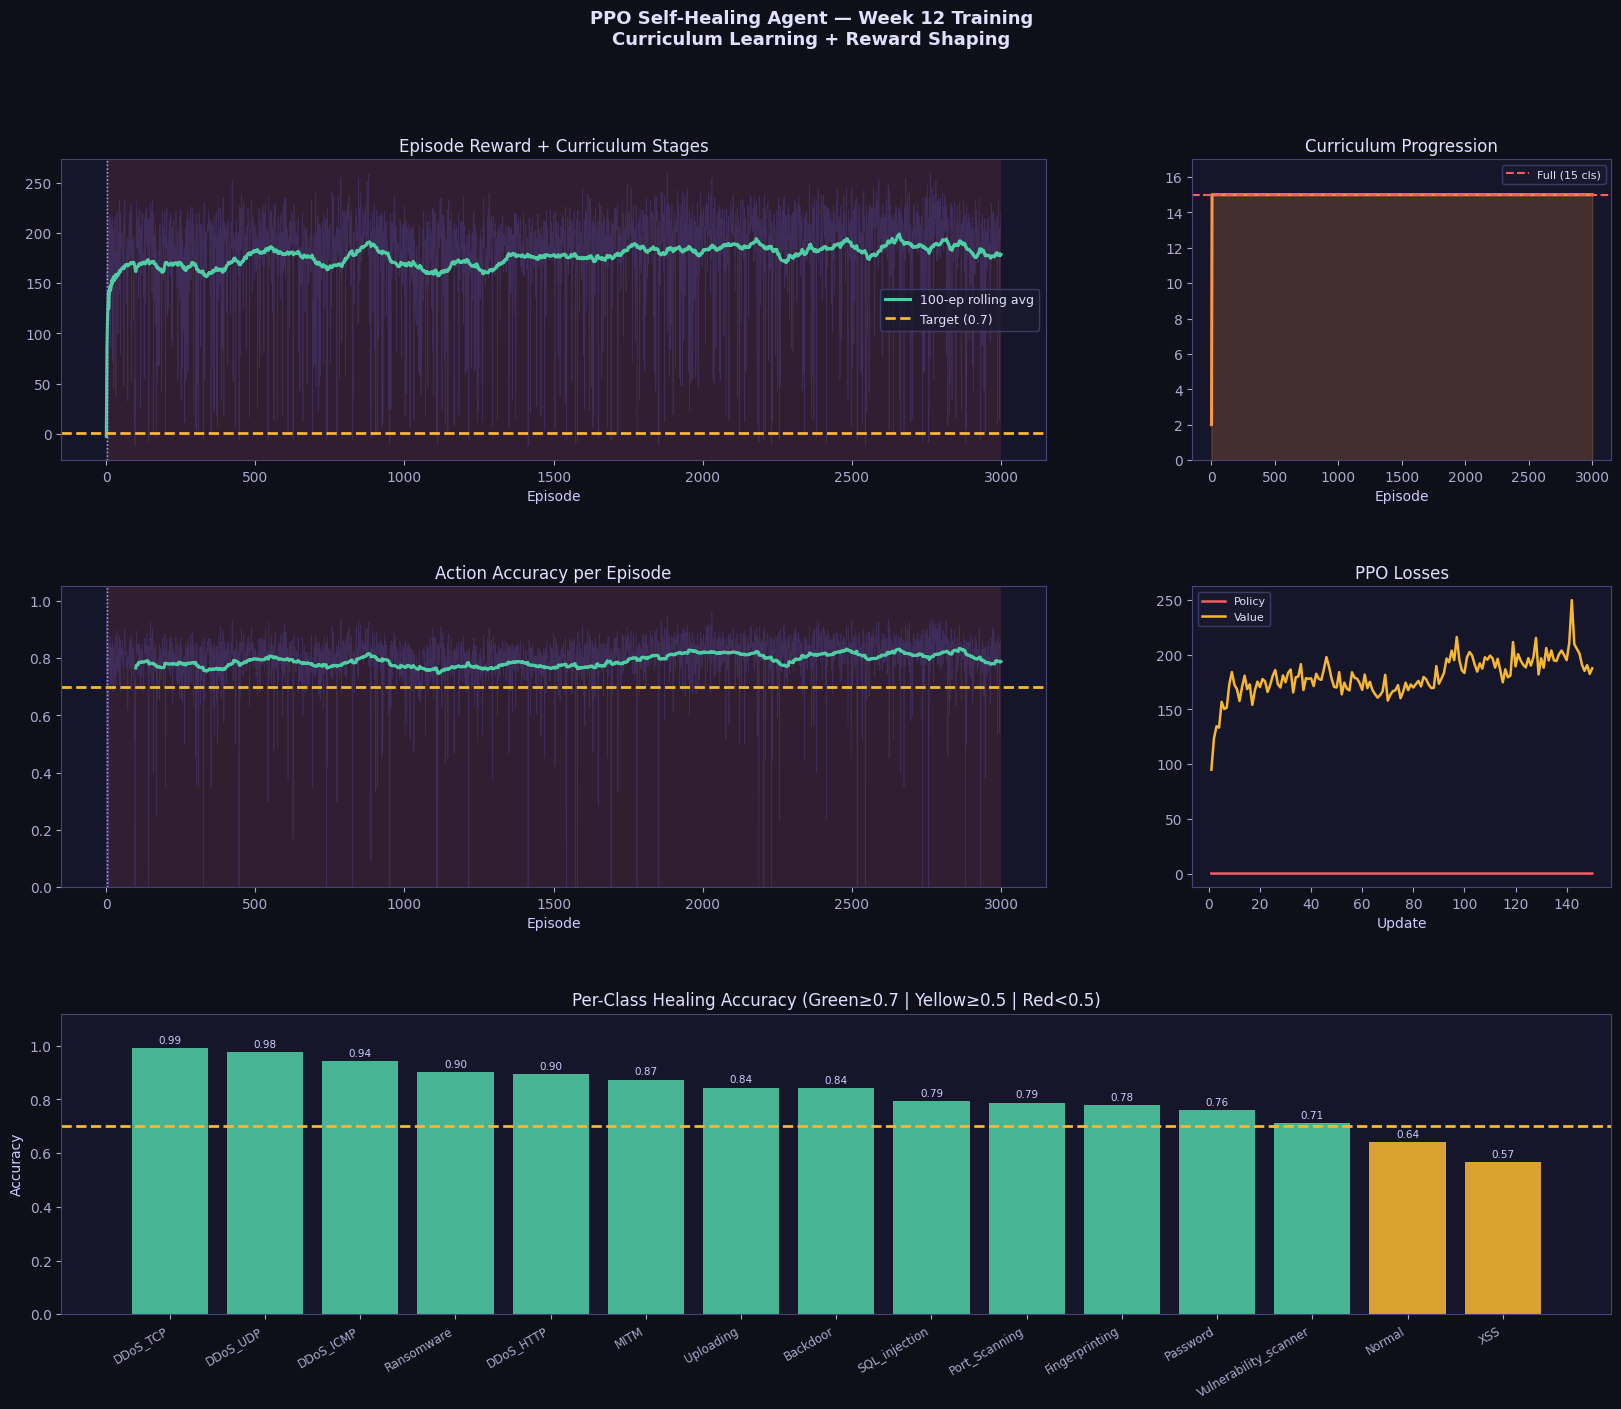

In [8]:
# ── Training plots ━━━━
eps_x   = list(range(1, N_EPISODES + 1))
upd_x   = list(range(1, len(history['policy_loss']) + 1))
S_COLORS= ['#7c6cfa22','#4ecca322','#f7b73122','#fc5c6522']
def shade(ax, advances):
    bounds = [0] + [e for e,_ in advances] + [N_EPISODES]
    for i in range(len(bounds)-1): ax.axvspan(bounds[i], bounds[i+1], alpha=0.12, color=S_COLORS[min(i,3)], linewidth=0)
    for ep,_ in advances: ax.axvline(ep, color='#aaaacc', linewidth=1, linestyle=':', alpha=0.6)

fig = plt.figure(figsize=(20, 15))
fig.suptitle('PPO Self-Healing Agent — Week 12 Training\nCurriculum Learning + Reward Shaping', fontsize=13, fontweight='bold', color='#e0e0ff')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.35)
ax = fig.add_subplot(gs[0, :2])
ax.plot(eps_x, history['ep_rewards'], color=ACCENT, alpha=0.2, linewidth=0.5)
ax.plot(eps_x, history['rolling_reward'], color=GREEN, linewidth=2.2, label='100-ep rolling avg')
ax.axhline(TARGET_REWARD, color=YELLOW, linewidth=2, linestyle='--', label=f'Target ({TARGET_REWARD})')
shade(ax, scheduler.advances)
ax.set_title('Episode Reward + Curriculum Stages'); ax.set_xlabel('Episode'); ax.legend(fontsize=9);

ax = fig.add_subplot(gs[0, 2])
if history['n_active_classes']:
    ax.plot(eps_x, history['n_active_classes'], color=ORANGE, linewidth=2.2)
    ax.fill_between(eps_x, history['n_active_classes'], alpha=0.2, color=ORANGE)
    ax.axhline(N_CLASSES, color=RED, linewidth=1.5, linestyle='--', label=f'Full ({N_CLASSES} cls)')
    ax.set_ylim(0, N_CLASSES+2); ax.set_title('Curriculum Progression'); ax.set_xlabel('Episode'); ax.legend(fontsize=8);

ax = fig.add_subplot(gs[1, :2])
roll_acc = pd.Series(history['ep_accuracy']).rolling(100).mean()
ax.plot(eps_x, history['ep_accuracy'], color=ACCENT, alpha=0.2, linewidth=0.5)
ax.plot(eps_x, roll_acc, color=GREEN, linewidth=2.2)
ax.axhline(TARGET_REWARD, color=YELLOW, linewidth=2, linestyle='--')
shade(ax, scheduler.advances); ax.set_title('Action Accuracy per Episode'); ax.set_xlabel('Episode'); ax.set_ylim(0,1.05);

ax = fig.add_subplot(gs[1, 2])
if upd_x:
    ax.plot(upd_x, history['policy_loss'], color=RED, linewidth=1.8, label='Policy')
    ax.plot(upd_x, history['value_loss'], color=YELLOW, linewidth=1.8, label='Value')
    ax.set_title('PPO Losses'); ax.set_xlabel('Update'); ax.legend(loc='upper left', fontsize=8);

ax = fig.add_subplot(gs[2, :])
final_ca = {cls: np.mean(class_acc_snaps[cls][-10:]) if class_acc_snaps[cls] else 0.0 for cls in CLASS_NAMES}
sorted_ca = sorted(final_ca.items(), key=lambda x: -x[1])
c_names, c_vals = [x[0] for x in sorted_ca], [x[1] for x in sorted_ca]
colors = [GREEN if v>=TARGET_REWARD else YELLOW if v>=0.5 else RED for v in c_vals]
bars = ax.bar(range(len(c_names)), c_vals, color=colors, edgecolor='none', alpha=0.88)
ax.set_xticks(range(len(c_names))); ax.set_xticklabels(c_names, rotation=30, ha='right', fontsize=8.5)
ax.axhline(TARGET_REWARD, color=YELLOW, linewidth=2, linestyle='--'); ax.set_ylim(0, 1.12); ax.set_ylabel('Accuracy')
ax.set_title(f'Per-Class Healing Accuracy (Green≥{TARGET_REWARD} | Yellow≥0.5 | Red<0.5)')
ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=7.5, color='#ccccff'); plt.tight_layout(); plt.show()


In [9]:
# ── Full evaluation on all 15 classes ━━━━━━━━━━━━━━━━━━━━━━━━━
if BEST_CKPT.exists():
    bc = torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False)
    agent.network.load_state_dict(bc['model_state_dict'])
    print(f'✅ Best checkpoint loaded (ep {bc["episode"]}, reward={bc["best_reward"]: .4f})')
agent.network.eval()
eval_sched = CurriculumScheduler(); eval_sched.idx = len(CurriculumScheduler.STAGES) - 1
eval_env   = CurriculumSecurityEnv(eval_sched, reward_engine)
state      = eval_env.reset(); e_correct = defaultdict(int); e_total = defaultdict(int); e_corr_all = []
for _ in range(5000):
    with torch.no_grad(): action, _, _ = agent.select_action(state)
    state, reward, done, info = eval_env.step(action); cls = info['true_class']
    e_total[cls]+=1; e_correct[cls]+=int(info['is_correct']); e_corr_all.append(int(info['is_correct']))
    if done: state = eval_env.reset()
overall_acc = float(np.mean(e_corr_all))
print(f'\n  Overall Accuracy : {overall_acc*100:.2f}%')

✅ Best checkpoint loaded (ep 2659, reward= 199.0187)

  Overall Accuracy : 83.80%


In [10]:
# ── Save trained agent + JSON report ━━━━━━━━━━━━━━━━━━
agent.save(BEST_CKPT, N_EPISODES, extra={'history': history, 'eval_reward': float(np.mean(history['ep_rewards'][-100:]))})
report = {'week': 12, 'best_reward': float(agent.best_reward), 'target': TARGET_REWARD, 'met': bool(agent.best_reward>=TARGET_REWARD)}
with open(REP_DIR / 'week12_report.json', 'w') as f: json.dump(report, f, indent=2)
print(f'\n✅ Week 12 Complete. SavedBEST_CKPT.')


✅ Week 12 Complete. SavedBEST_CKPT.


---
## ✅ Summary — Week 12 Outputs

| Artefact | Location |
|----------|----------|
| Best trained agent | `checkpoints/ppo_agent_trained.pt` |
| Evaluation report | `outputs/reports/week12_report.json` |
